分析在SOFA环境下，三维海绵控制的结果分析

上游代码 -> `3DSimEnv.py`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import matplotlib.font_manager as fm
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

---
contact_list = [10, 11, 12, 13] + [32, 33, 34, 35]; 
fixed_list = [206, 207, 208, 209] + [228, 229, 230, 231]

learning_rate=5.e-1; max_action=8.e-3

In [4]:
num:int = 1

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
marker_pos_np = np.loadtxt(f'marker_pos_list{num}.csv', delimiter=',')
contact_pos_np = np.loadtxt(f'contact_pos_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_mov_list{num}.csv', delimiter=',')
step_num = loss_np.shape[0]

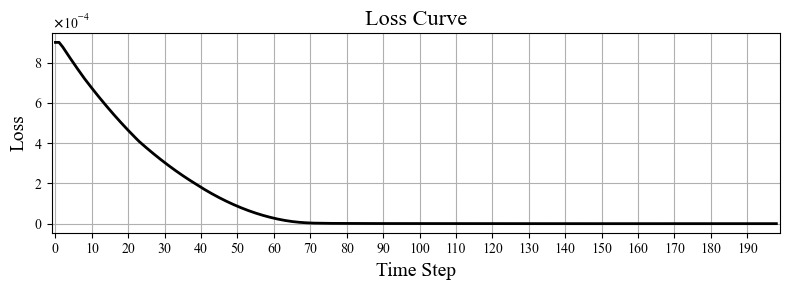

In [12]:
fig = plt.figure(figsize=(8, 3), dpi=100)
gs = GridSpec(1, 1, figure=fig)

plot_step_num = step_num
axs_loss = fig.add_subplot(gs[0, :])
axs_loss.plot(loss_np[:plot_step_num], marker='', markerfacecolor='white', linestyle='-', linewidth=2, color='black')
axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
axs_loss.set_ylabel('Loss', fontsize=14, fontname='Times New Roman')
axs_loss.set_xlim([-1, plot_step_num])
axs_loss.xaxis.set_major_locator(MultipleLocator(10))
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss.grid(True)

fig.tight_layout()

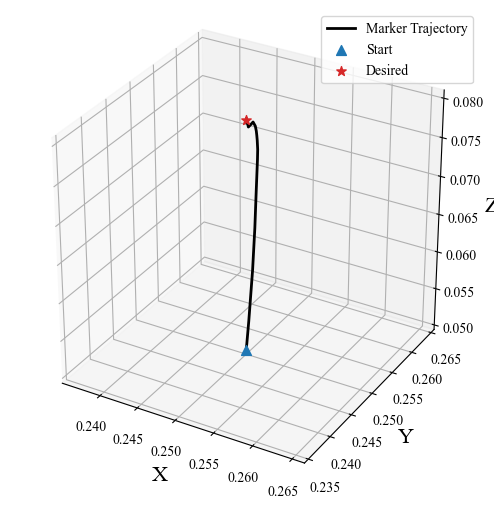

In [55]:
x = marker_pos_np[:, 0]
y = marker_pos_np[:, 1]
z = marker_pos_np[:, 2]

# 创建三维图形
fig = plt.figure(figsize=(6, 5), dpi=100)
gs = GridSpec(1, 1, figure=fig)

ax = fig.add_subplot(gs[0, 0], projection='3d')
ax.plot(marker_pos_np[:, 0], marker_pos_np[:, 1], marker_pos_np[:, 2], label='Marker Trajectory', color='black', linewidth=2)
ax.scatter(marker_pos_np[0, 0], marker_pos_np[0, 1], marker_pos_np[0, 2], label='Start', marker='^', color='tab:blue', s=50)
ax.scatter(marker_pos_np[0, 0], marker_pos_np[0, 1], marker_pos_np[0, 2]+0.03, label='Desired', marker='*', color='tab:red', s=50)
ax.set_xlabel('X', fontsize=16)
ax.set_ylabel('Y', fontsize=16)
ax.set_zlabel('Z', fontsize=16)
ax.legend()

# ax.view_init(elev=0, azim=20)

# 设置轴比例相同（类似 axis_equal 的效果）
max_range = np.array([x.max() - x.min(), y.max() - y.min(), z.max() - z.min()]).max() / 2.0

mid_x = (x.max() + x.min()) * 0.5
mid_y = (y.max() + y.min()) * 0.5
mid_z = (z.max() + z.min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

ax.set_box_aspect([1, 1, 1])

fig.tight_layout()

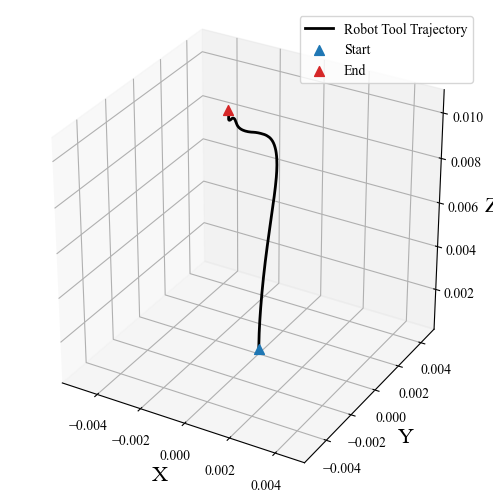

In [54]:
rob_pos_np = np.cumsum(rob_mov_np, axis=0)

x = rob_pos_np[:, 0]
y = rob_pos_np[:, 1]
z = rob_pos_np[:, 2]

# 创建三维图形
fig = plt.figure(figsize=(6, 5), dpi=100)
gs = GridSpec(1, 1, figure=fig)

ax = fig.add_subplot(gs[0, 0], projection='3d')
ax.plot(rob_pos_np[:, 0], rob_pos_np[:, 1], rob_pos_np[:, 2], label='Robot Tool Trajectory', color='black', linewidth=2)
ax.scatter(rob_pos_np[0, 0], rob_pos_np[0, 1], rob_pos_np[0, 2], label='Start', marker='^', color='tab:blue', s=50)
ax.scatter(rob_pos_np[-1, 0], rob_pos_np[-1, 1], rob_pos_np[-1, 2], label='End', marker='^', color='tab:red', s=50)
ax.set_xlabel('X', fontsize=16)
ax.set_ylabel('Y', fontsize=16)
ax.set_zlabel('Z', fontsize=16)
ax.legend()

# 设置轴比例相同（类似 axis_equal 的效果）
max_range = np.array([x.max() - x.min(), y.max() - y.min(), z.max() - z.min()]).max() / 2.0

mid_x = (x.max() + x.min()) * 0.5
mid_y = (y.max() + y.min()) * 0.5
mid_z = (z.max() + z.min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

ax.set_box_aspect([1, 1, 1])

fig.tight_layout()

---


In [3]:
num:int = 2

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
marker_pos_np = np.loadtxt(f'marker_pos_list{num}.csv', delimiter=',')
contact_pos_np = np.loadtxt(f'contact_pos_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_mov_list{num}.csv', delimiter=',')
step_num = loss_np.shape[0]

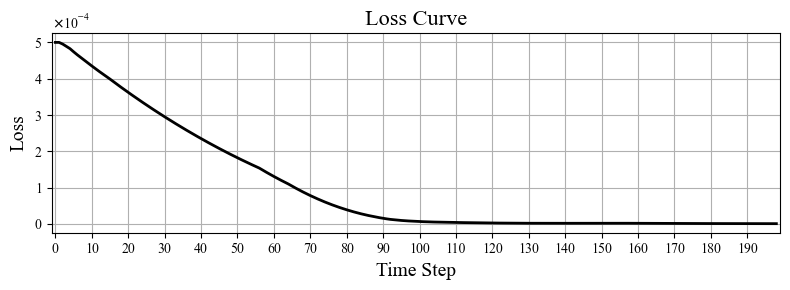

In [4]:
fig = plt.figure(figsize=(8, 3), dpi=100)
gs = GridSpec(1, 1, figure=fig)

plot_step_num = step_num
axs_loss = fig.add_subplot(gs[0, :])
axs_loss.plot(loss_np[:plot_step_num], marker='', markerfacecolor='white', linestyle='-', linewidth=2, color='black')
axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
axs_loss.set_ylabel('Loss', fontsize=14, fontname='Times New Roman')
axs_loss.set_xlim([-1, plot_step_num])
axs_loss.xaxis.set_major_locator(MultipleLocator(10))
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss.grid(True)

fig.tight_layout()